In [2]:
# ============================================================
# CELL 1 — GPU Setup
# ============================================================
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ GPU detected: {gpus}")
else:
    print("❌ No GPU, running on CPU")

✅ GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
# ============================================================
# CELL 2 — Imports
# ============================================================
import numpy as np
import pandas as pd
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

!pip install shap pyarrow

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
import shap
import os

✅ Imports done


In [10]:
# ============================================================
# CELL 3 — Paths  (update to your Kaggle paths)
# ============================================================
DATASET_PATH      = "/kaggle/input/datasets/muhammadasad29/ember24/New folder"
TRAIN_PATH        = f"{DATASET_PATH}/ember24_win64_train.parquet"
TEST_PATH         = f"{DATASET_PATH}/ember24_win64_test.parquet"
FEATURE_COLS_JSON = "/kaggle/input/datasets/muhammadasad29/ember24-feature-cols/ember24_client1_feature_cols.json"

In [11]:
# ============================================================
# CELL 4 — Load Data
# ============================================================
print("Loading train...")
train_df = pd.read_parquet(TRAIN_PATH)
print("Loading test...")
test_df  = pd.read_parquet(TEST_PATH)

print(f"Train shape : {train_df.shape}")
print(f"Test  shape : {test_df.shape}")

Loading train...
Loading test...
Train shape : (720000, 898)
Test  shape : (160000, 945)


In [12]:
# ============================================================
# CELL 5 — Find Label Column
# ============================================================
LABEL_COL = None
for col in train_df.columns:
    if col.lower() == 'label':
        LABEL_COL = col
        break

if LABEL_COL is None:
    raise ValueError("❌ Label column not found.")

print(f"✅ Label column: '{LABEL_COL}'")
print("\nTrain label distribution:")
print(train_df[LABEL_COL].value_counts())
print("\nTest label distribution:")
print(test_df[LABEL_COL].value_counts())

✅ Label column: 'label'

Train label distribution:
label
1    360000
0    360000
Name: count, dtype: int64

Test label distribution:
label
1    80000
0    80000
Name: count, dtype: int64


In [13]:
# ============================================================
# CELL 6 — Filter Unlabeled (-1) Rows
# ============================================================
train_df = train_df[train_df[LABEL_COL] != -1].reset_index(drop=True)
test_df  = test_df[test_df[LABEL_COL]   != -1].reset_index(drop=True)

print(f"After filtering — Train: {train_df.shape}, Test: {test_df.shape}")

After filtering — Train: (720000, 898), Test: (160000, 945)


In [14]:
# ============================================================
# CELL 7 — Load Feature Columns from JSON
# ============================================================
with open(FEATURE_COLS_JSON, "r") as f:
    feature_cols = json.load(f)

# Keep only features that exist in both train and test
feature_cols = [c for c in feature_cols
                if c in train_df.columns and c in test_df.columns]

print(f"✅ Using {len(feature_cols)} feature columns")

✅ Using 890 feature columns


In [15]:
# ============================================================
# CELL 8 — Split X / y
# ============================================================
X_train = train_df[feature_cols].values.astype("float32")
y_train = train_df[LABEL_COL].values.astype("float32")

X_test  = test_df[feature_cols].values.astype("float32")
y_test  = test_df[LABEL_COL].values.astype("float32")

del train_df, test_df
import gc; gc.collect()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

X_train : (720000, 890)
X_test  : (160000, 890)


In [16]:
# ============================================================
# CELL 9 — Clean NaN / Inf using Median (same as client notebooks)
# ============================================================
print(f"NaNs before : {np.isnan(X_train).sum()}")

X_train = np.where(np.isinf(X_train), np.nan, X_train)
X_test  = np.where(np.isinf(X_test),  np.nan, X_test)

# Fill NaN with column median (computed from train only)
col_medians = np.nanmedian(X_train, axis=0)
for i in range(X_train.shape[1]):
    X_train[:, i] = np.where(np.isnan(X_train[:, i]), col_medians[i], X_train[:, i])
    X_test[:, i]  = np.where(np.isnan(X_test[:, i]),  col_medians[i], X_test[:, i])

print(f"NaNs after  : {np.isnan(X_train).sum()}")
print("✅ Median fill done")

NaNs before : 85628412
NaNs after  : 0
✅ Median fill done


In [17]:
# ============================================================
# CELL 10 — Scale
# ============================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Clip after scaling to prevent extreme scaled values
X_train = np.clip(X_train, -10, 10)
X_test  = np.clip(X_test,  -10, 10)

print("✅ Scaling done")
print(f"X_train mean: {X_train.mean():.4f}, std: {X_train.std():.4f}")

✅ Scaling done
X_train mean: -0.0068, std: 0.6685


In [19]:
# ============================================================
# CELL 11 — Model  (same architecture as client notebooks)
# ============================================================
n_features = X_train.shape[1]

model = Sequential([
    Input(shape=(n_features,)),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │       456,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 590,849 (2.25 MB)

 Trainable params: 589,313 (2.25 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [20]:
# ============================================================
# CELL 12 — Train
# ============================================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30


I0000 00:00:1777996884.897201     154 service.cc:152] XLA service 0x7e1a84031410 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777996884.897243     154 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777996884.897247     154 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777996885.439410     154 cuda_dnn.cc:529] Loaded cuDNN version 91002


  44/1266 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8134 - loss: 0.4394

I0000 00:00:1777996888.004407     154 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1266/1266 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9076 - loss: 0.2364 - val_accuracy: 0.9326 - val_loss: 0.1614
Epoch 2/30
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9405 - loss: 0.1537 - val_accuracy: 0.9368 - val_loss: 0.1620
Epoch 3/30
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9458 - loss: 0.1397 - val_accuracy: 0.9443 - val_loss: 0.1403
Epoch 4/30
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9499 - loss: 0.1294 - val_accuracy: 0.9411 - val_loss: 0.1552
Epoch 5/30
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9523 - loss: 0.1243 - val_accuracy: 0.9486 - val_loss: 0.1409
Epoch 6/30
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9545 - loss: 0.1173 - val_accuracy: 0.9500 - val_loss: 0.1238
Epoch 7/30
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9560 - loss: 0.1129 - val_accuracy: 0.9495 - val_loss: 0.1280
Epoch 8/30
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9583 - loss: 0.1085 - val_accura

In [21]:
# ============================================================
# CELL 13 — Evaluate
# ============================================================
y_pred_prob = model.predict(X_test).ravel()
y_pred      = (y_pred_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_prob)

print("=" * 50)
print("   EMBER24 CENTRAL MODEL — TEST RESULTS")
print("=" * 50)
print(f"   Accuracy : {acc:.4f}")
print(f"   F1 Score : {f1:.4f}")
print(f"   ROC-AUC  : {roc:.4f}")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=["Benign", "Malware"]))

5000/5000 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
   EMBER24 CENTRAL MODEL — TEST RESULTS
   Accuracy : 0.9417
   F1 Score : 0.9400
   ROC-AUC  : 0.9835
              precision    recall  f1-score   support

      Benign       0.92      0.97      0.94     80000
     Malware       0.97      0.91      0.94     80000

    accuracy                           0.94    160000
   macro avg       0.94      0.94      0.94    160000
weighted avg       0.94      0.94      0.94    160000



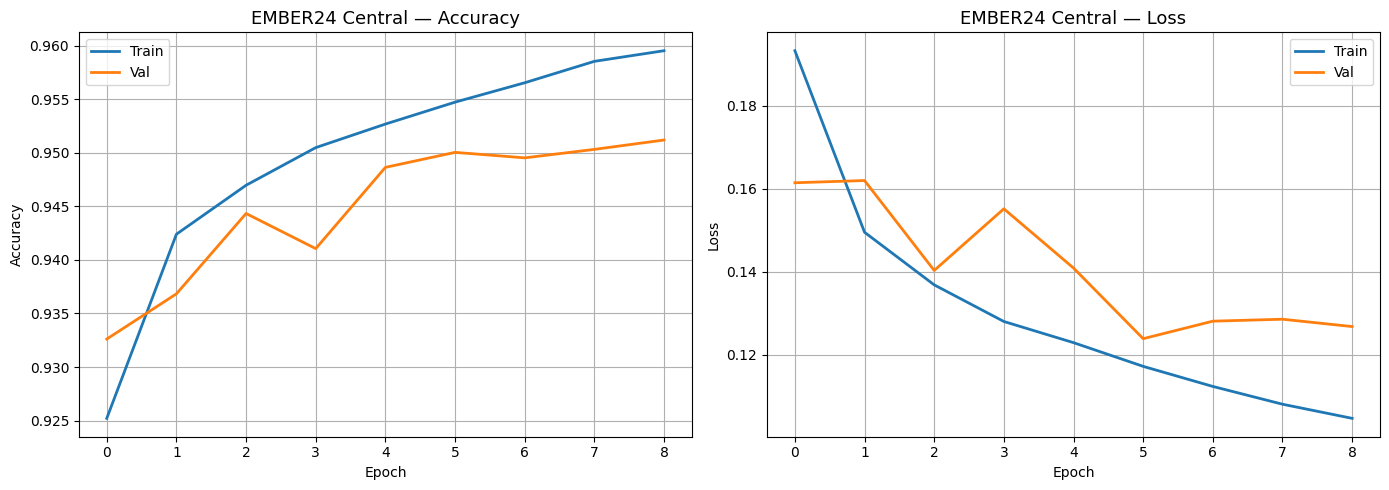

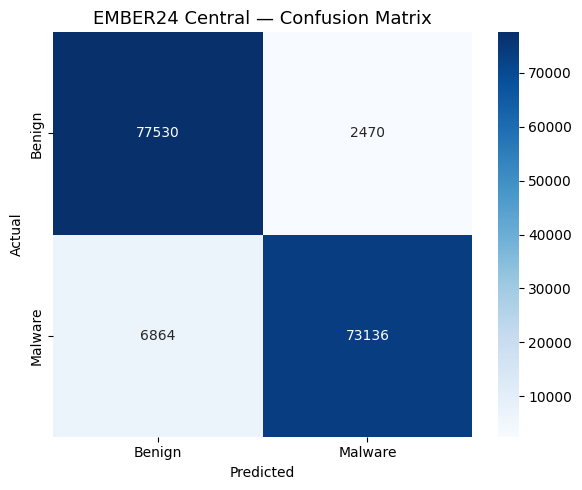

In [22]:
# ============================================================
# CELL 14 — Plots
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   linewidth=2)
axes[0].set_title('EMBER24 Central — Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val',   linewidth=2)
axes[1].set_title('EMBER24 Central — Loss', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig("/kaggle/working/ember24_central_training_curves.png", dpi=150)
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Benign", "Malware"],
            yticklabels=["Benign", "Malware"])
plt.title("EMBER24 Central — Confusion Matrix", fontsize=13)
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("/kaggle/working/ember24_central_confusion_matrix.png", dpi=150)
plt.show()

In [23]:
# ============================================================
# CELL 15 — Save
# ============================================================
model.save("/kaggle/working/ember24_central_model.keras")
model.save_weights("/kaggle/working/ember24_central_weights.weights.h5")
joblib.dump(scaler, "/kaggle/working/ember24_central_scaler.pkl")

with open("/kaggle/working/ember24_central_feature_cols.json", "w") as f:
    json.dump(feature_cols, f)

results = {
    "Client"    : ["Central (EMBER24)"],
    "Data Size" : [X_train.shape[0]],
    "Features"  : [X_train.shape[1]],
    "Accuracy"  : [round(acc, 4)],
    "F1 Score"  : [round(f1, 4)],
    "ROC-AUC"   : [round(roc, 4)],
}
pd.DataFrame(results).to_csv("/kaggle/working/ember24_central_results.csv", index=False)

print("✅ ember24_central_model.keras")
print("✅ ember24_central_weights.weights.h5")
print("✅ ember24_central_scaler.pkl")
print("✅ ember24_central_feature_cols.json")
print("✅ ember24_central_results.csv")

✅ ember24_central_model.keras
✅ ember24_central_weights.weights.h5
✅ ember24_central_scaler.pkl
✅ ember24_central_feature_cols.json
✅ ember24_central_results.csv
